In [28]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')


/kaggle/input/datasets/mnassrib/jena-climate/jena_climate_2009_2016.csv


In [29]:
import torch
import numpy as np

print(f"PyTorch Version: {torch.__version__}")

# 1. The Divine Fire: Checking if the GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")

print("\n--- NumPy vs PyTorch Practice ---")

# 2. Creating a 2D array in NumPy (something you know)
np_array = np.array([[1.0, 2.0], [3.0, 4.0]])
print(f"NumPy Array:\n{np_array} (Type: {type(np_array)})")

# 3. Forging a PyTorch Tensor from that NumPy array
py_tensor = torch.from_numpy(np_array)
print(f"PyTorch Tensor:\n{py_tensor} (Type: {type(py_tensor)})")

# 4. Sending your tensor to the GPU warrior
if torch.cuda.is_available():
    gpu_tensor = py_tensor.to(device)
    print(f"\nTensor successfully sent to GPU! Device property: {gpu_tensor.device}")

PyTorch Version: 2.10.0+cpu
Using device: cpu

--- NumPy vs PyTorch Practice ---
NumPy Array:
[[1. 2.]
 [3. 4.]] (Type: <class 'numpy.ndarray'>)
PyTorch Tensor:
tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64) (Type: <class 'torch.Tensor'>)


# Testing for GPU

In [30]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

dataset_path = '/kaggle/input/datasets/mnassrib/jena-climate/jena_climate_2009_2016.csv'
df = pd.read_csv(dataset_path)

#sampling from 10 minute to 1 hour intervals as our requirement is in hours
#starting from 5th index,we take every 6th row as i hour is 60 minutes
df = df.iloc[5::6].reset_index(drop=True)

# we drop'Date Time' string column
features = df[['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']].values

#80 percent for training and 20 percent for testing
split_idx_raw = int(len(features) * 0.8)
train_features = features[:split_idx_raw]
test_features = features[split_idx_raw:]

# Fit scaler only on training data, then transform both
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_features)
test_scaled = scaler.transform(test_features)

#recombining vertically so the sliding window loop works perfectly
features_scaled = np.vstack((train_scaled, test_scaled))

# IMPORTING THE JENA CLIMATE DATASET

In [31]:
X = []
y = []

seq_length = 72
forecast_offset = 12
temp_index = 1 # 'T (degC)' is at index 1 in our features list

print("sliding windows")

for i in range(len(features_scaled) - seq_length - forecast_offset):
    # The 72 hour input sequence of 14 features
    window = features_scaled[i : i + seq_length]
    
    target = features[i + seq_length + forecast_offset - 1, temp_index]
   
    
    X.append(window)
    y.append(target)

#lists to tensors
X_tensor = torch.tensor(np.array(X), dtype=torch.float32)
y_tensor = torch.tensor(np.array(y), dtype=torch.float32)

print(f"Total Number Sequences : {len(X_tensor)}")
print(f"Shape of X_tensor: {X_tensor.shape} -> [Batches, Sequence Length, Features]")

sliding windows
Total Number Sequences : 70007
Shape of X_tensor: torch.Size([70007, 72, 14]) -> [Batches, Sequence Length, Features]


# Preparing the Sliding Window

In [32]:
class JenaDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels
        
    def __len__(self):
        return len(self.sequences)
        
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

#we split the data chronologically and seperate test and train set (80% goes for training and 20% goes for testing in chronological order)

split_idx = int(len(X_tensor) * 0.8)

train_dataset = JenaDataset(X_tensor[:split_idx], y_tensor[:split_idx])
test_dataset = JenaDataset(X_tensor[split_idx:], y_tensor[split_idx:])

#dataloaders
#batch size 256 is ok for 1D tensors
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

#verification
sequences, labels = next(iter(train_loader))
print(f"First Batch X shape: {sequences.shape}")
print(f"First Batch Y shape: {labels.shape}")
print(sequences[0][0])#will have 14 elements in the tensor 

First Batch X shape: torch.Size([256, 72, 14])
First Batch Y shape: torch.Size([256])
tensor([ 1.1026,  0.5796,  0.4860,  0.5312, -0.4721,  0.3622,  0.3790,  0.2453,
         0.3512,  0.3536, -0.2852,  0.2336, -0.1875,  1.1563])


# Preparing the dataloders

# THE 5 GOVERNING EQUATIONS OF LSTM
**Forget Gate ($f_t$): $f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$**

**Input Gate ($i_t$): $i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$** 

**Candidate State ($\tilde{C}_t$): $\tilde{C}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c)$**

**Cell State Update ($C_t$): $C_t = f_t * C_{t-1} + i_t * \tilde{C}_t$**

**Output Gate & Hidden State ($h_t$): $o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \rightarrow h_t = o_t * \tanh(C_t)$**

In [33]:
import torch
import torch.nn as nn

class LSTM(nn.Module):
    def __init__(self, input_size=14, hidden_size=64, output=1):
        super().__init__()
        self.input_size = input_size
        
        # hidden dimension should be between 32 and 256
        self.hidden_size = hidden_size 
        
        # We concatenate the current input (x_t) and previous hidden state (h_{t-1})
        # So the weight matrices must accept the combined size
        combined_size = input_size + hidden_size
        
        # Forget Gate: decides what past memory to erase
        self.W_f = nn.Linear(combined_size, hidden_size)
        
        # Input Gate: decides what new information to let in
        self.W_i = nn.Linear(combined_size, hidden_size)
        
        # Candidate Cell State: the new potential information to add
        self.W_c = nn.Linear(combined_size, hidden_size)
        
        #  Output Gate: Decides what part of the memory becomes the new hidden state
        self.W_o = nn.Linear(combined_size, hidden_size)
        
        # Final Classifier
        self.fc = nn.Linear(hidden_size, output)

    def forward(self, x):
        # x shape gives [Batch_Size, Sequence_Length, Features],example [256, 72, 14]
        batch_size, seq_len, _ = x.size()
        device = x.device
        
        # initializing both hidden and cell state to all zeroes
        h_t = torch.zeros(batch_size, self.hidden_size).to(device)
        c_t = torch.zeros(batch_size, self.hidden_size).to(device)
        
        # Sliding through the 72 hours step by step
        for t in range(seq_len):
            #extracting the weather features for the current hour t
            x_t = x[:, t, :] 
            
            #concatenate current input and previous hidden state horizontally
            combined = torch.cat((x_t, h_t), dim=1)
            
            # applying the 5 LSTM equations mentioned above 
            
            #Forget Gate (sigmoid function brings the value between 0 and 1, 0 = forgetten completely)
            f_t = torch.sigmoid(self.W_f(combined))
            
            #Input Gate
            i_t = torch.sigmoid(self.W_i(combined))
            
            #Candidate cell state (Tanh function brings the value between -1 and 1)
            c_tilde = torch.tanh(self.W_c(combined))
            
            #Update cell state(Long Term Memory)
            c_t = (f_t * c_t) + (i_t * c_tilde)
            
            #output gate and the final hidden state updation
            o_t = torch.sigmoid(self.W_o(combined))
            h_t = o_t * torch.tanh(c_t)
            
        # after looping through all 72 hours, we take the hidden state
        # and pass it to our fully connected layer to make the prediction
        out = self.fc(h_t)
        return out

model=LSTM().to(device)
print(model)

LSTM(
  (W_f): Linear(in_features=78, out_features=64, bias=True)
  (W_i): Linear(in_features=78, out_features=64, bias=True)
  (W_c): Linear(in_features=78, out_features=64, bias=True)
  (W_o): Linear(in_features=78, out_features=64, bias=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


# Building The LSTM

--- Beginning of Training (Training the model) ---
  [Epoch 1, Batch 100] Loss(MSE): 84.4285
  [Epoch 1, Batch 200] Loss(MSE): 40.4704
Epoch [1/25] | Train Loss(MSE): 60.0165 | Val Loss: 36.7966
  [Epoch 2, Batch 100] Loss(MSE): 23.9295
  [Epoch 2, Batch 200] Loss(MSE): 17.6608
Epoch [2/25] | Train Loss(MSE): 20.3059 | Val Loss: 16.5748
  [Epoch 3, Batch 100] Loss(MSE): 13.2062
  [Epoch 3, Batch 200] Loss(MSE): 10.9440
Epoch [3/25] | Train Loss(MSE): 11.9306 | Val Loss: 11.5970
  [Epoch 4, Batch 100] Loss(MSE): 9.5571
  [Epoch 4, Batch 200] Loss(MSE): 8.7489
Epoch [4/25] | Train Loss(MSE): 9.0775 | Val Loss: 9.3884
  [Epoch 5, Batch 100] Loss(MSE): 8.0877
  [Epoch 5, Batch 200] Loss(MSE): 7.7482
Epoch [5/25] | Train Loss(MSE): 7.8904 | Val Loss: 8.4534
  [Epoch 6, Batch 100] Loss(MSE): 7.3297
  [Epoch 6, Batch 200] Loss(MSE): 7.0745
Epoch [6/25] | Train Loss(MSE): 7.1746 | Val Loss: 7.9377
  [Epoch 7, Batch 100] Loss(MSE): 6.8128
  [Epoch 7, Batch 200] Loss(MSE): 6.6680
Epoch [7/25] | 

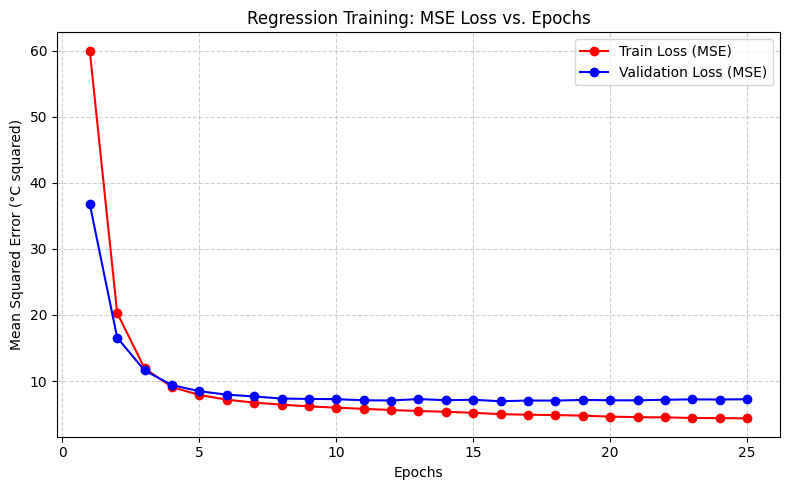

In [34]:
#  Baseline Training
import torch.optim as optim
import matplotlib.pyplot as plot
loss_history=[]
val_loss_history = []
batch_loss_history=[]

# 1.Loss Function and Optimizer

criterion = nn.MSELoss()
# Adam is a highly efficient optimizer that dynamically adjusts the learning rate
optimizer = optim.Adam(model.parameters(), lr=0.001)#lr=learning rate

# factor=0.5 means cut Learning rate in half. patience=2 means wait 2 epochs of no improvement before cutting.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# 2.Training Loop

#An Epoch is one complete pass through the entire library
epochs=25
print("--- Beginning of Training (Training the model) ---")
for epoch in range(epochs):
    model.train() # Set the model to training mode
    running_loss = 0.0
    running_batch_loss=0.0
    
    for i, (inputs, labels) in enumerate(train_loader):#batch numbers,images,answers
        # Moving the batched data to  GPU
        inputs, labels = inputs.to(device), labels.to(device)

        # Step 1: Clear the old gradients from the last step
        optimizer.zero_grad()

        # Step 2: forward pass (make blind guess)
        outputs = model(inputs)
        
        # Step 3: Calculate the loss (How wrong was the prediction?)
        loss = criterion(outputs.squeeze(), labels.float())

        # Step 4: Backward Pass (Calculate the gradients),backpropagation
        loss.backward()

        # Step 5: Optimize (Update the models weights)
        optimizer.step()

        running_loss += loss.item()
        running_batch_loss += loss.item()
        # Jena Climate dataset has roughly 420,000 ,we divided into hours so by 6 which is 70,000
        #80 percent of 70,000 is y 56,000
        #56,000 by 256(batch_size) which is approx 218(when floored)
        if i % 100 == 99:
            print(f"  [Epoch {epoch + 1}, Batch {i + 1}] Loss(MSE): {running_batch_loss / 100:.4f}")
            batch_loss_history.append(running_batch_loss / 100)
            running_batch_loss = 0.0


    # calculating average loss for the epoch
    epoch_train_loss = running_loss / len(train_loader)
    
    loss_history.append(epoch_train_loss)


# --- VALIDATION PHASE ---
    model.eval() # Set model to evaluation mode 
    running_val_loss = 0.0
    
    # torch.no_grad() disables gradient calculation to save memory and compute
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), labels.float())
            
            running_val_loss += loss.item()
            
    
            
    epoch_val_loss = running_val_loss / len(test_loader)
    val_loss_history.append(epoch_val_loss)
    scheduler.step(epoch_val_loss)
    
    # Print metrics for the epoch
    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss(MSE): {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}")

            

print("--- Training Completed ---")

# 3. Plotting Results against Epochs
epochs_range = range(1, epochs + 1)

plot.figure(figsize=(8, 5))
plot.plot(epochs_range, loss_history, label='Train Loss (MSE)', color='red', marker='o')
plot.plot(epochs_range, val_loss_history, label='Validation Loss (MSE)', color='blue', marker='o')
plot.title('Regression Training: MSE Loss vs. Epochs')
plot.xlabel('Epochs')
plot.ylabel('Mean Squared Error (°C squared)')
plot.legend()
plot.grid(True, linestyle='--', alpha=0.6)

plot.tight_layout()
plot.show()

# Validation and Train Loss Curves

--- Running Final Evaluation ---

--- Final Regression Metrics ---
Mean Squared Error (MSE):  7.2505
Mean Absolute Error (MAE): 2.1016 °C
Huber Loss:                1.6521


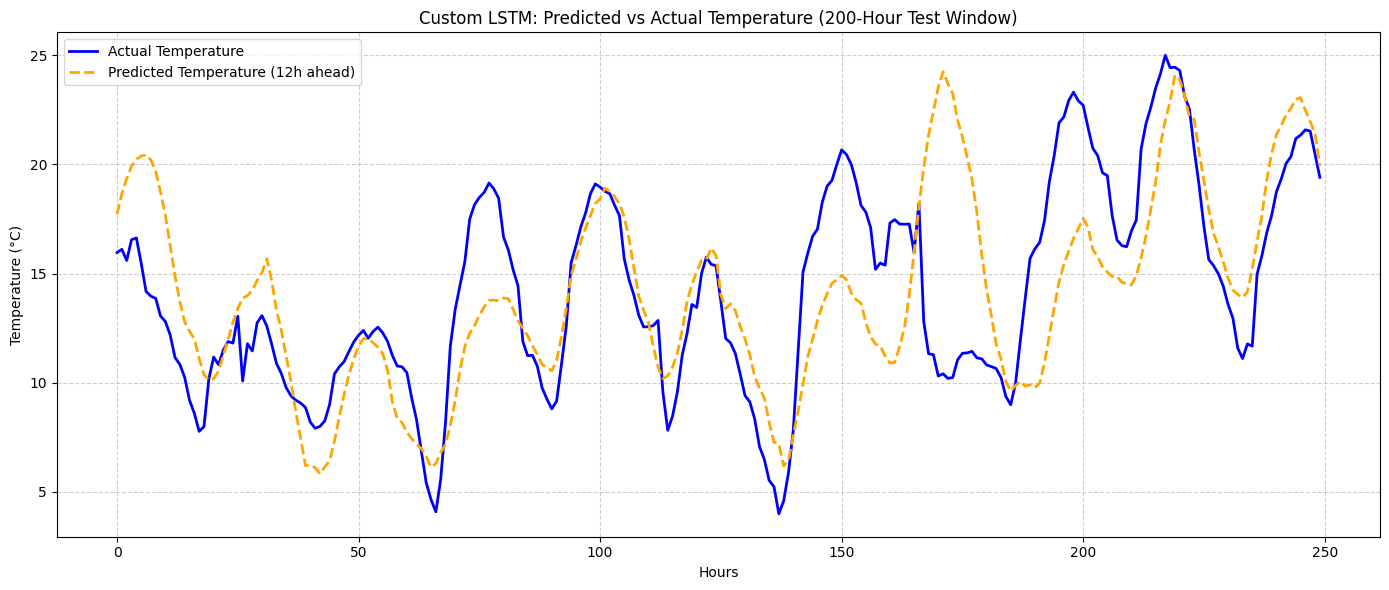

In [36]:
import torch.nn.functional as F
import torch

# 1. Setup for Evaluation
model.eval()
all_predictions = []
all_actuals = []

print("--- Running Final Evaluation ---")

# 2. Collect all predictions and actual targets from the test set
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        
        # Squeeze outputs to make them 1D, just like the labels
        outputs = model(inputs).squeeze() 
        
        # Move back to CPU and convert to lists for metric calculation
        all_predictions.extend(outputs.cpu().numpy())
        all_actuals.extend(labels.cpu().numpy())

# Convert lists to PyTorch tensors for PyTorch's built-in loss functions
preds_tensor = torch.tensor(all_predictions)
actuals_tensor = torch.tensor(all_actuals)

# 3. Calculate Final Mentor-Requested Metrics
mse = F.mse_loss(preds_tensor, actuals_tensor)
mae = F.l1_loss(preds_tensor, actuals_tensor)
huber = F.huber_loss(preds_tensor, actuals_tensor)

print("\n--- Final Regression Metrics ---")
print(f"Mean Squared Error (MSE):  {mse.item():.4f}")
print(f"Mean Absolute Error (MAE): {mae.item():.4f} °C")
print(f"Huber Loss:                {huber.item():.4f}")

# 4. Generate the Single Comparison Plot
# We'll plot a 200-hour window from the test set to get a clear view of the curves
window_size = 250 

plot.figure(figsize=(14, 6))
plot.plot(all_actuals[:window_size], label='Actual Temperature', color='blue', linewidth=2)
plot.plot(all_predictions[:window_size], label='Predicted Temperature (12h ahead)', color='orange', linestyle='dashed', linewidth=2)

plot.title('Custom LSTM: Predicted vs Actual Temperature (200-Hour Test Window)')
plot.xlabel('Hours')
plot.ylabel('Temperature (°C)')
plot.legend()
plot.grid(True, linestyle='--', alpha=0.6)
plot.tight_layout()
plot.show()

# Prediction vs Actual Comparision

In [40]:
torch.save(model.state_dict(), '/kaggle/working/LSTM_weights.pth')
print("Model weights saved successfully to /kaggle/working/LSTM_weights.pth!")

Model weights saved successfully to /kaggle/working/LSTM_weights.pth!


# Saving Model Weights